# FarmTech Solutions — Previsão de Rendimento de Safra e Análise de Tendências (Fase 5)

**Integrantes do grupo:** Caroline Coelho Mendes RM570370 - 
Leandro Paiva RM572159 - 
Lucas Viana de Lima RM571835

**Disciplina:** Cap 1 - FarmTech na Era da Cloud Computing — FIAP
**Base de dados:** `crop_yield.csv`

---

## 1. Contexto

A FarmTech Solutions presta serviços de IA para uma fazenda de médio porte (~200 hectares) que produz
várias culturas agrícolas. Este notebook cumpre a **Entrega 1** do projeto, que consiste em:

1. **Análise exploratória (EDA)** da base `crop_yield.csv` para entender a distribuição e a relação entre as variáveis;
2. **Clusterização** (aprendizado não supervisionado — Capítulo 10) para identificar tendências de produtividade
   e cenários discrepantes (*outliers*) entre os registros de solo/clima;
3. **Cinco modelos preditivos** (Capítulo "Modelagem de Dados com Regressão Supervisionada" — Fase 4), cada um
   usando um algoritmo diferente, para prever o **Rendimento (Yield)** da safra a partir das condições de solo e clima.

### Sobre a base de dados

| Coluna | Descrição |
|---|---|
| `Crop` | Nome da cultura agrícola |
| `Precipitation (mm day-1)` | Precipitação em mm/dia |
| `Specific Humidity at 2 Meters (g/kg)` | Umidade específica a 2m (g de vapor d'água por kg de ar seco) |
| `Relative Humidity at 2 Meters (%)` | Umidade relativa a 2m (%) |
| `Temperature at 2 Meters (C)` | Temperatura a 2m (°C) |
| `Yield` | Rendimento da safra — **variável alvo (target)** |


## 2. Importação das bibliotecas

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, GroupKFold, cross_validate

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 3. Leitura e preparação inicial dos dados

Antes de qualquer análise, lemos o arquivo crop_yield.csv, padronizamos os nomes das colunas e conferimos os tipos de dados e a presença de valores ausentes.


In [2]:
df = pd.read_csv("crop_yield.csv")
df.columns = [c.strip() for c in df.columns]

print("Dimensão do dataset:", df.shape)
df.head()


Dimensão do dataset: (156, 6)


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    str    
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 9.4 KB


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Precipitation (mm day-1),156.0,2486.498974,289.457914,1934.62,2302.99,2424.55,2718.08,3085.79
Specific Humidity at 2 Meters (g/kg),156.0,18.203077,0.293923,17.54,18.03,18.27,18.40,18.70
Relative Humidity at 2 Meters (%),156.0,84.737692,0.996226,82.11,84.12,84.85,85.51,86.10
Temperature at 2 Meters (C),156.0,26.183590,0.261050,25.56,26.02,26.13,26.30,26.81
Yield,156.0,56153.096154,70421.958897,5249.00,8327.75,18871.00,67518.75,203399.00


In [5]:
df.isnull().sum()


Crop                                    0
Precipitation (mm day-1)                0
Specific Humidity at 2 Meters (g/kg)    0
Relative Humidity at 2 Meters (%)       0
Temperature at 2 Meters (C)             0
Yield                                   0
dtype: int64

In [6]:
df["Crop"].value_counts()


Crop
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64

In [7]:
duplicadas = df.duplicated().sum()
print(f"Linhas duplicadas encontradas: {duplicadas}")
if duplicadas > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicatas removidas. Nova dimensão:", df.shape)


Linhas duplicadas encontradas: 0


### 3.1 Estrutura escondida da base: as mesmas condições climáticas se repetem entre culturas

Antes de seguir para a EDA, vale investigar algo importante para toda a análise posterior: quantas
combinações climáticas distintas (precipitação, umidade específica, umidade relativa e temperatura)
existem na base, e se elas se repetem entre culturas.


In [8]:
colunas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
features_cluster = [c for c in colunas_numericas if c != "Yield"]

combinacoes_climaticas = df[features_cluster].round(6).drop_duplicates()
print(f"Registros totais: {len(df)}")
print(f"Combinações climáticas (precipitação/umidade/temperatura) distintas: {len(combinacoes_climaticas)}")

culturas_por_combinacao = df.groupby(features_cluster)["Crop"].nunique()
print(f"Combinações em que as 4 culturas aparecem: {(culturas_por_combinacao == df['Crop'].nunique()).sum()} de {len(culturas_por_combinacao)}")


Registros totais: 156
Combinações climáticas (precipitação/umidade/temperatura) distintas: 39
Combinações em que as 4 culturas aparecem: 39 de 39


**Achado importante:** existem apenas 39 combinações climáticas distintas para 156 registros, 
ou seja, cada cenário climático se repete exatamente 4 vezes, uma vez para cada uma das 4 culturas da
base. Isso significa que Crop e as variáveis climáticas são estatisticamente independentes neste
dataset (o desenho experimental aplica os mesmos 39 cenários climáticos a todas as culturas). Esse achado
é decisivo para interpretar corretamente tanto a clusterização (seção 5) quanto os modelos preditivos
(seção 6) mais adiante — sem ele, seria fácil (e errado) concluir que os agrupamentos climáticos
"representam" as culturas.


## 4. Análise Exploratória de Dados (EDA)

Nesta etapa buscamos entender a distribuição de cada variável, possíveis assimetrias, a relação entre
as variáveis climáticas/de solo e o rendimento (Yield), e diferenças de rendimento entre culturas.


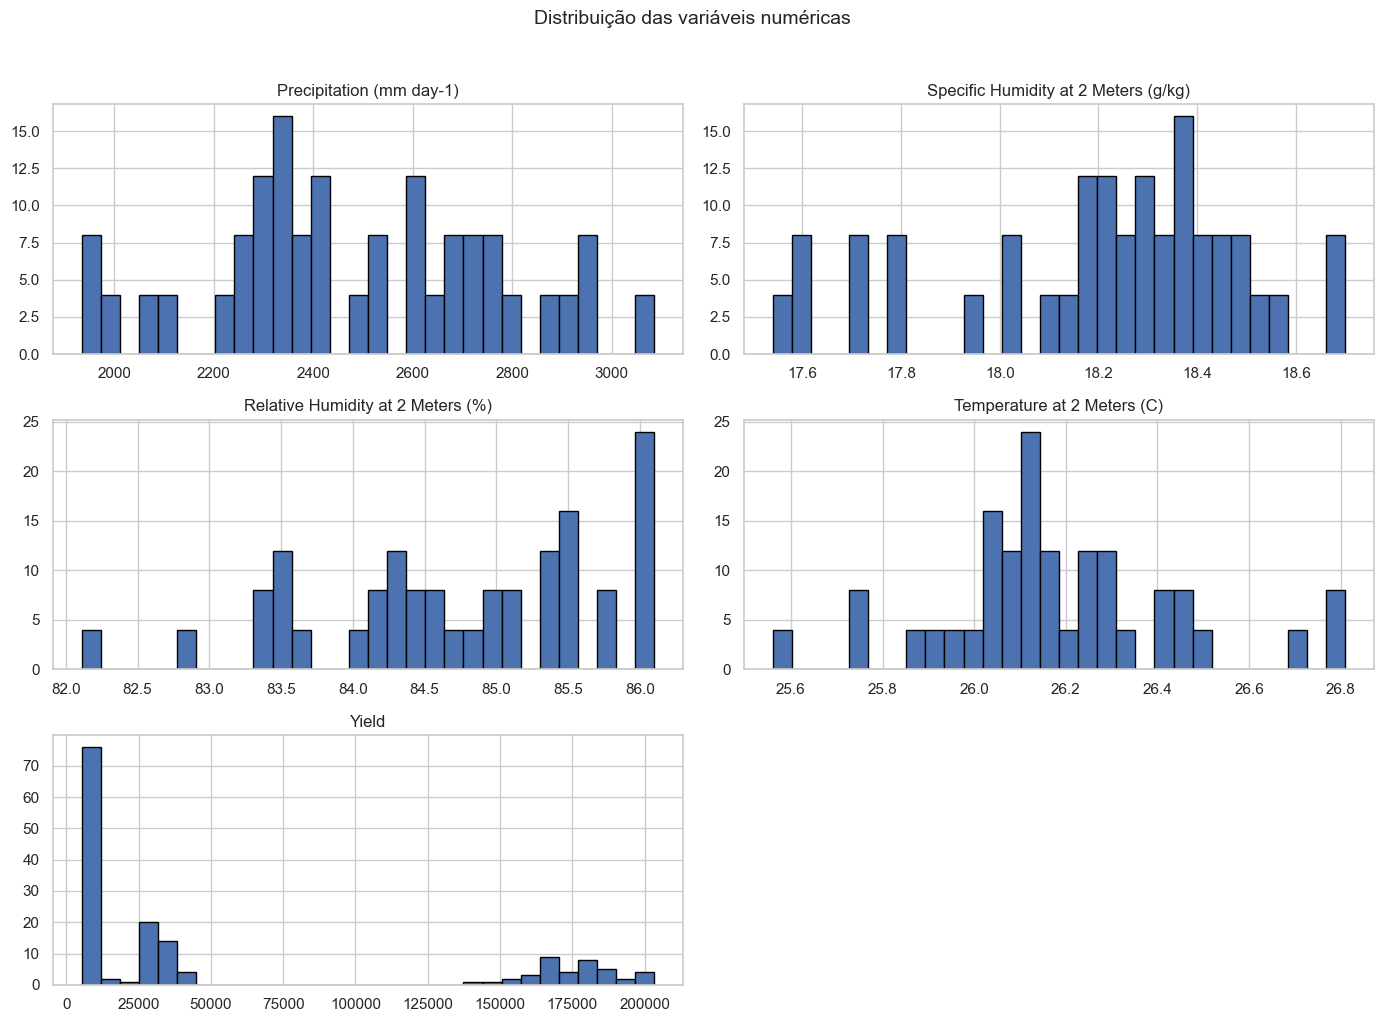

In [9]:
df[colunas_numericas].hist(bins=30, figsize=(14, 10), edgecolor="black")
plt.suptitle("Distribuição das variáveis numéricas", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


Interpretação: As variáveis apresentam escalas bastante diferentes entre si, especialmente o Yield, cujo intervalo é muito superior ao das variáveis climáticas. Essa diferença de escala reforça a importância da padronização das variáveis nos algoritmos baseados em distância e também indica que o rendimento deve ser analisado com atenção às diferenças entre culturas.

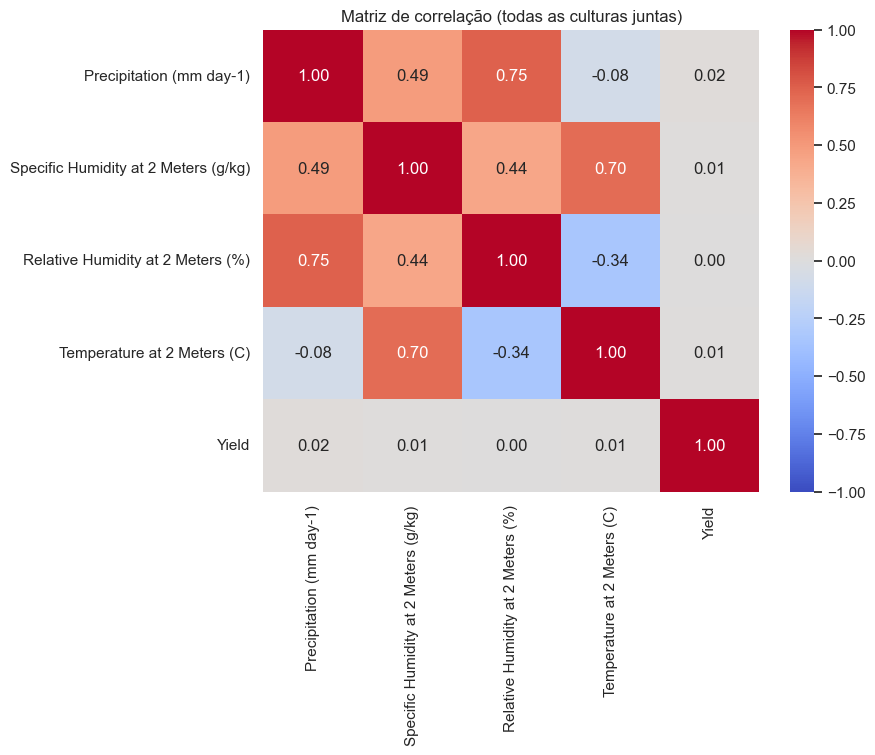

Precipitation (mm day-1)                0.018830
Specific Humidity at 2 Meters (g/kg)    0.012651
Relative Humidity at 2 Meters (%)       0.000008
Temperature at 2 Meters (C)             0.013007
Yield                                   1.000000
Name: Yield, dtype: float64

In [10]:
plt.figure(figsize=(8, 6))
corr_global = df[colunas_numericas].corr()
sns.heatmap(corr_global, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlação (todas as culturas juntas)")
plt.show()

corr_global["Yield"]


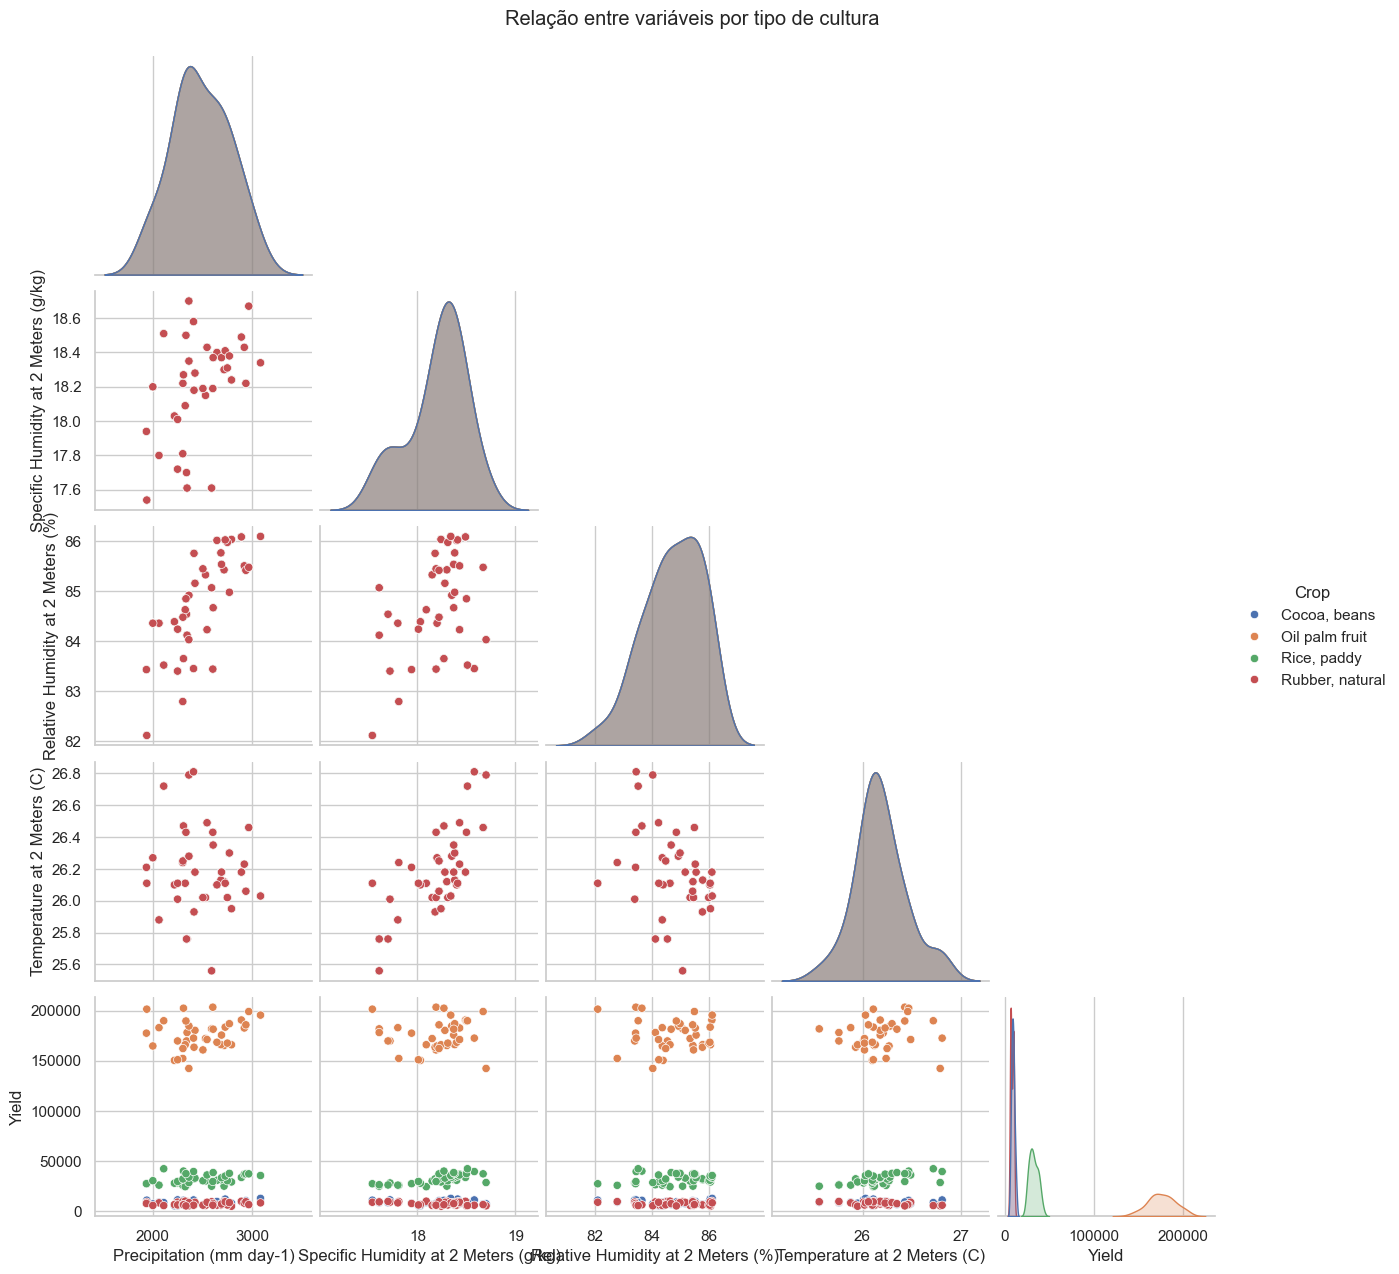

In [11]:
sns.pairplot(df, vars=colunas_numericas, hue="Crop", diag_kind="kde", corner=True)
plt.suptitle("Relação entre variáveis por tipo de cultura", y=1.02)
plt.show()


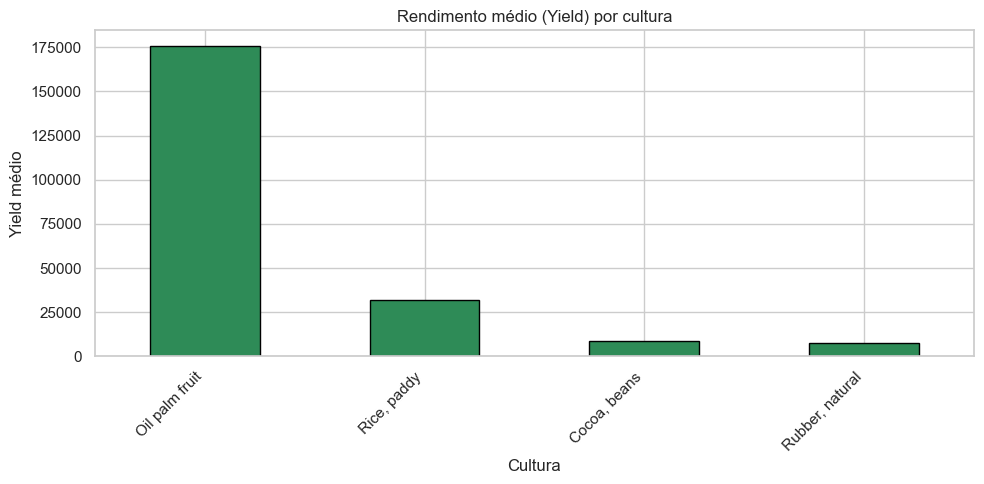

Crop
Oil palm fruit     175804.692308
Rice, paddy         32099.666667
Cocoa, beans         8883.128205
Rubber, natural      7824.897436
Name: Yield, dtype: float64

In [12]:
rendimento_por_cultura = df.groupby("Crop")["Yield"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
rendimento_por_cultura.plot(kind="bar", color="seagreen", edgecolor="black")
plt.title("Rendimento médio (Yield) por cultura")
plt.ylabel("Yield médio")
plt.xlabel("Cultura")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

rendimento_por_cultura


Interpretação: Existe uma diferença expressiva no rendimento médio entre as culturas, com destaque para Oil palm fruit, cujo Yield é muito superior ao das demais. Essa diferença ajuda a explicar por que a variável Crop terá forte influência nos modelos de previsão.

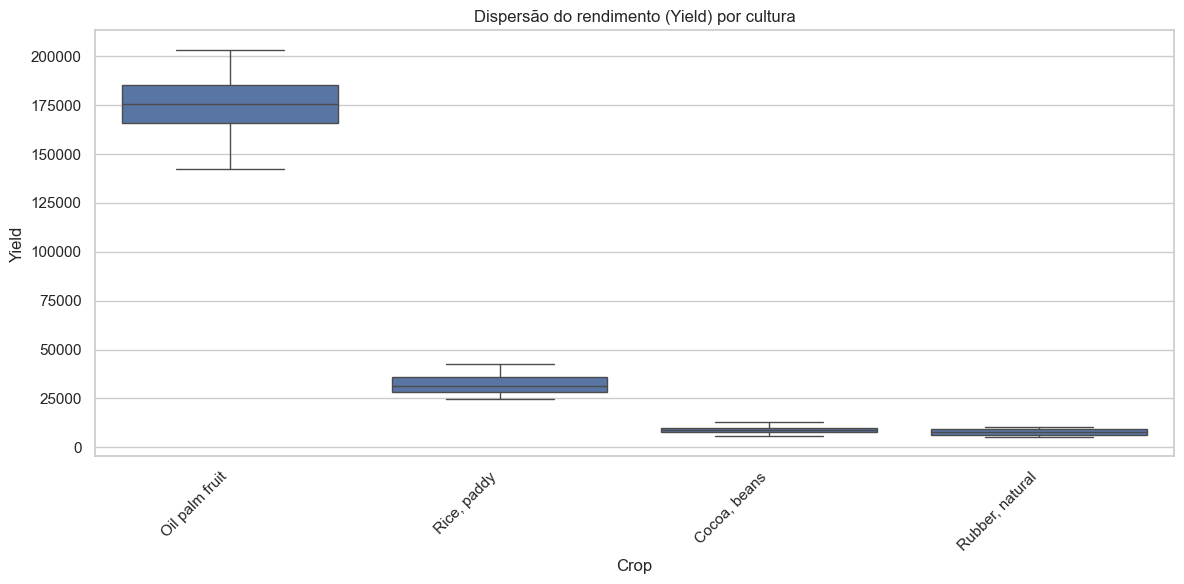

In [13]:
plt.figure(figsize=(12, 6))
ordem = df.groupby("Crop")["Yield"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="Crop", y="Yield", order=ordem)
plt.xticks(rotation=45, ha="right")
plt.title("Dispersão do rendimento (Yield) por cultura")
plt.tight_layout()
plt.show()


Interpretação: Além das diferenças nas médias, o boxplot mostra como a distribuição e a dispersão do rendimento também variam entre as culturas. Por isso, comparar valores de Yield entre diferentes culturas sem considerar suas escalas pode levar a conclusões equivocadas.

### 4.1 Correlação clima × Yield calculada dentro de cada cultura

A matriz de correlação global mostra correlações praticamente nulas entre as
variáveis climáticas e o Yield (todas abaixo de 0,02 em módulo). Isso não significa que o clima não
importe — significa que, quando todas as culturas são misturadas, a enorme diferença de patamar de
rendimento entre culturas domina a variância do Yield e "esconde" o efeito do clima. Para investigar o
efeito real do clima, recalculamos a correlação separadamente para cada cultura.


In [14]:
for cultura in df["Crop"].unique():
    sub = df[df["Crop"] == cultura]
    corr_cultura = sub[features_cluster + ["Yield"]].corr()["Yield"].drop("Yield")
    print(f"--- Correlação com Yield dentro de '{cultura}' (n={len(sub)}) ---")
    print(corr_cultura.round(3).to_string())
    print()


--- Correlação com Yield dentro de 'Cocoa, beans' (n=39) ---
Precipitation (mm day-1)                0.174
Specific Humidity at 2 Meters (g/kg)   -0.055
Relative Humidity at 2 Meters (%)      -0.058
Temperature at 2 Meters (C)            -0.010

--- Correlação com Yield dentro de 'Oil palm fruit' (n=39) ---
Precipitation (mm day-1)                0.222
Specific Humidity at 2 Meters (g/kg)    0.071
Relative Humidity at 2 Meters (%)      -0.035
Temperature at 2 Meters (C)             0.097

--- Correlação com Yield dentro de 'Rice, paddy' (n=39) ---
Precipitation (mm day-1)                0.329
Specific Humidity at 2 Meters (g/kg)    0.697
Relative Humidity at 2 Meters (%)       0.150
Temperature at 2 Meters (C)             0.609

--- Correlação com Yield dentro de 'Rubber, natural' (n=39) ---
Precipitation (mm day-1)                0.101
Specific Humidity at 2 Meters (g/kg)   -0.434
Relative Humidity at 2 Meters (%)      -0.054
Temperature at 2 Meters (C)            -0.407



### 4.2 Síntese da EDA

- **156 registros, 4 culturas** (Cocoa beans, Oil palm fruit, Rice paddy e Rubber natural), 39 combinações
  por cultura, sem valores nulos ou duplicados.
- **Rendimento médio por cultura** é extremamente diferente em ordem de grandeza:
  - Oil palm fruit: **≈ 175.805**
  - Rice paddy: **≈ 32.100**
  - Cocoa beans: **≈ 8.883**
  - Rubber natural: **≈ 7.825**

  Essa diferença de escala é o fator que mais explica a variância do Yield na base como um todo — muito
  mais do que qualquer variável climática isolada.
- **Correlação global** entre clima e Yield é próxima de zero (todas |r| < 0,02), justamente por causa
  dessa mistura de escalas entre culturas.
- **Dentro de cada cultura**, porém, aparecem relações climáticas relevantes que a correlação global
  esconde. Por exemplo, em Rice, paddy: Specific Humidity tem correlação de ≈ 0,70 com o Yield
  e Temperature tem correlação de ≈ 0,61 — ambas moderadas a fortes. Já em Rubber, natural, a
  correlação de Specific Humidity e Temperature com o Yield é negativa (≈ -0,43 e ≈ -0,41,
  respectivamente) — um padrão oposto ao de Rice.
- **Conclusão prática:** para investigar o efeito do clima sobre a produtividade, é preciso analisar
  **dentro de cada cultura**, nunca a base inteira misturada — e essa lição orienta como interpretamos os
  clusters e os modelos preditivos nas próximas seções.


## 5. Clusterização — Tendências Climáticas e Outliers

Conforme o Capítulo 10 (*Machine Learning Sem Supervisão*), usamos algoritmos de clusterização para:

1. Encontrar agrupamentos naturais de condições climáticas (K-Means);
2. Identificar cenários climáticos discrepantes (outliers) usando o DBSCAN.

Como vimos na seção 3.1, Crop é independente das variáveis climáticas nesta base (cada cenário climático
se repete igualmente nas 4 culturas). Por isso, a clusterização aqui é feita apenas com as variáveis
climáticas (sem o Yield e sem Crop) — o objetivo é agrupar cenários climáticos, não culturas nem
rendimentos. Como os algoritmos de clusterização se baseiam em distância entre pontos, padronizamos
(escalamos) as variáveis antes de aplicá-los.


In [15]:
X_cluster = df[features_cluster].copy()

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

X_cluster_scaled[:5]


array([[-0.82341547, -1.64884495, -1.34708396, -0.66710937],
       [-1.89956502, -2.26322349, -2.64614077, -0.28280708],
       [-0.64104192, -1.34165569, -1.96136664,  0.21678591],
       [ 0.36686484, -2.0242985 ,  0.33464075, -2.39646972],
       [-0.49138608, -2.0242985 , -0.62202899, -1.62786512]])

### 5.1 K-Means — Definindo o número ideal de clusters

Usamos o método do cotovelo (Elbow Method) e o coeficiente de silhueta para apoiar a escolha
do número de clusters `K`.


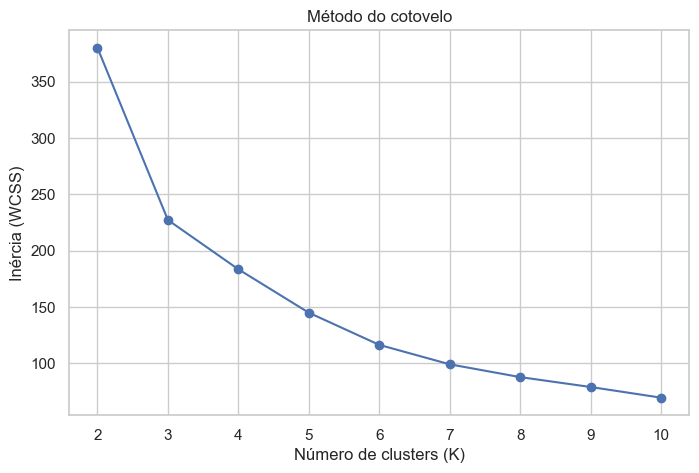

In [16]:
inercias = []
faixa_k = range(2, 11)

for k in faixa_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(faixa_k), inercias, "-o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inércia (WCSS)")
plt.title("Método do cotovelo")
plt.show()


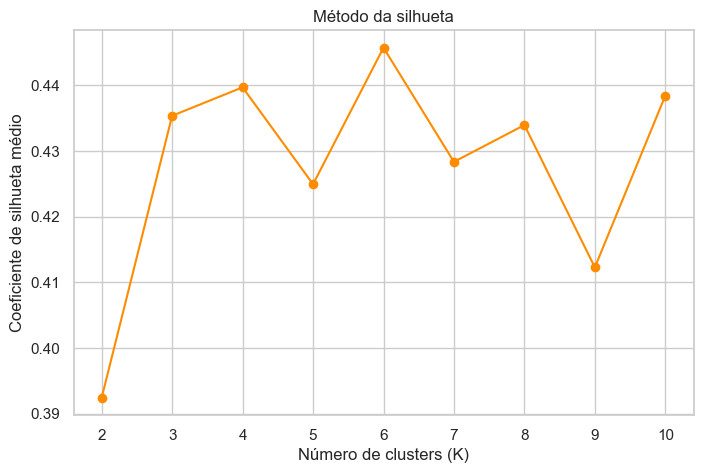

K=2: silhueta média = 0.392
K=3: silhueta média = 0.435
K=4: silhueta média = 0.440
K=5: silhueta média = 0.425
K=6: silhueta média = 0.446
K=7: silhueta média = 0.428
K=8: silhueta média = 0.434
K=9: silhueta média = 0.412
K=10: silhueta média = 0.438


In [17]:
silhuetas = []

for k in faixa_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_cluster_scaled)
    silhuetas.append(silhouette_score(X_cluster_scaled, labels_k))

plt.figure(figsize=(8, 5))
plt.plot(list(faixa_k), silhuetas, "-o", color="darkorange")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Coeficiente de silhueta médio")
plt.title("Método da silhueta")
plt.show()

for k, s in zip(faixa_k, silhuetas):
    print(f"K={k}: silhueta média = {s:.3f}")


**Escolha de K:** a curva do cotovelo decresce de forma suave e contínua, sem uma quebra nítida em
nenhum ponto específico — portanto usamos o coeficiente de silhueta como critério de desempate. O
maior valor observado foi em K=6 (silhueta ≈ 0,446), levemente acima dos demais candidatos (K=3 a K=10
ficam todos entre ≈ 0,39 e ≈ 0,44). Optamos por K=6, o valor quantitativamente melhor segundo a
silhueta. Reforçando o que vimos na seção 3.1: como Crop é independente do clima nesta base, não faz
sentido escolher K com base no número de culturas — os clusters aqui representam perfis climáticos,
não categorias de cultura.


In [18]:
K_ESCOLHIDO = 6  

kmeans_final = KMeans(n_clusters=K_ESCOLHIDO, random_state=42, n_init=10)
df["cluster_kmeans"] = kmeans_final.fit_predict(X_cluster_scaled)

df["cluster_kmeans"].value_counts().sort_index()


cluster_kmeans
0    12
1    40
2    16
3    52
4    20
5    16
Name: count, dtype: int64

### 5.2 Visualizando os clusters com PCA

Variância explicada pelos 2 componentes: 93.44%


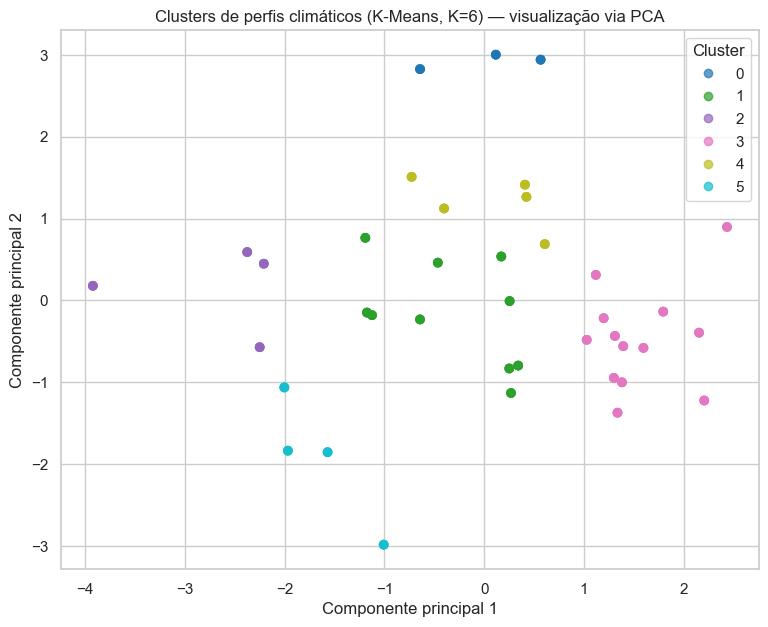

In [19]:
pca_viz = PCA(n_components=2, random_state=42)
componentes = pca_viz.fit_transform(X_cluster_scaled)

df["pca_1"] = componentes[:, 0]
df["pca_2"] = componentes[:, 1]

print(f"Variância explicada pelos 2 componentes: {pca_viz.explained_variance_ratio_.sum():.2%}")

plt.figure(figsize=(9, 7))
scatter = plt.scatter(df["pca_1"], df["pca_2"], c=df["cluster_kmeans"], cmap="tab10", alpha=0.7)
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title(f"Clusters de perfis climáticos (K-Means, K={K_ESCOLHIDO}) — visualização via PCA")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()


Interpretação: A projeção em duas dimensões pelo PCA permite visualizar os seis perfis climáticos encontrados pelo K-Means. Os dois componentes principais preservam aproximadamente 93,44% da variância dos dados, portanto essa representação resume bem a estrutura original. Ainda assim, as cores representam agrupamentos definidos no espaço completo das variáveis padronizadas, e não apenas pela posição no gráfico 2D.

In [20]:
df.groupby("cluster_kmeans")[features_cluster].mean()


,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C)
cluster_kmeans,,,,
0,2294.090000,18.596667,83.666667,26.773333
1,2333.406000,18.170000,84.872000,26.127000
2,2105.875000,17.752500,82.932500,26.142500
3,2814.984615,18.380000,85.722308,26.143846
4,2480.170000,18.352000,84.168000,26.434000
5,2334.495000,17.680000,84.522500,25.740000


### 5.3 Verificação obrigatória: os clusters representam culturas ou cenários climáticos?

Como cada cluster deveria, em tese, poder "coincidir" com uma cultura caso houvesse alguma relação entre
clima e cultura, verificamos diretamente a distribuição de culturas dentro de cada cluster.


In [21]:
tabela_cluster_cultura = pd.crosstab(df["cluster_kmeans"], df["Crop"])
tabela_cluster_cultura


Crop,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
cluster_kmeans,,,,
0,3,3,3,3
1,10,10,10,10
2,4,4,4,4
3,13,13,13,13
4,5,5,5,5
5,4,4,4,4


**Interpretação dos clusters (K-Means):** a tabela acima mostra que cada cluster contém exatamente
a mesma proporção das 4 culturas — ou seja, os clusters não separam culturas, eles agrupam perfis
climáticos (combinações de precipitação, umidade e temperatura) que, por construção do dataset, se
repetem igualmente entre todas as culturas. Isso confirma, com dados, o que já era esperado pela análise da
seção 3.1.

Como o Yield bruto tem escalas radicalmente diferentes por cultura (seção 4.2), não comparamos o
Yield médio diretamente entre clusters — isso misturaria o efeito do clima com o efeito da própria
cultura, levando à mesma armadilha de interpretação que a correlação global já havia mostrado (seção 4.1).
A forma correta de investigar se um perfil climático favorece maior produtividade é olhar o Yield médio
de cada cluster separado por cultura, o que fazemos a seguir.


In [22]:
df.pivot_table(index="cluster_kmeans", columns="Crop", values="Yield", aggfunc="mean").round(1)


Crop,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
cluster_kmeans,,,,
0,9332.7,168307.3,37051.3,5948.0
1,7438.6,165607.2,30679.6,7331.7
2,10142.2,175276.2,27440.8,9103.2
3,9527.3,179490.0,33598.7,8006.8
4,8692.4,189624.0,36581.2,7117.8
5,9043.0,178198.5,26121.2,9479.8


Com essa tabela é possível comparar, cultura a cultura, se algum cluster climático tende a apresentar
Yield mais alto ou mais baixo — uma leitura correta, já que a comparação é sempre feita dentro da mesma
cultura (mesma escala).


### 5.4 DBSCAN — Identificando cenários climáticos discrepantes (outliers)

Diferente do K-Means, o DBSCAN não exige a definição prévia do número de grupos e classifica como
ruído (outlier) os pontos que não pertencem a nenhuma região densa.

Antes de fixar os hiperparâmetros, testamos várias combinações de eps e min_samples e comparamos o
número de clusters e a proporção de outliers resultante — para não escolher um valor de forma arbitrária.


In [23]:
resultados_dbscan = []

for eps in [0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]:
    for min_samples in [3, 4, 5]:
        db_teste = DBSCAN(eps=eps, min_samples=min_samples).fit(X_cluster_scaled)
        labels_teste = db_teste.labels_
        n_out = int((labels_teste == -1).sum())
        n_clust = len(set(labels_teste)) - (1 if -1 in labels_teste else 0)
        resultados_dbscan.append({
            "eps": eps, "min_samples": min_samples,
            "clusters": n_clust, "outliers": n_out,
            "% outliers": round(100 * n_out / len(df), 1),
        })

df_dbscan_grid = pd.DataFrame(resultados_dbscan)
df_dbscan_grid


,eps,min_samples,clusters,outliers,% outliers
0,0.8,3,17,0,0.0
1,0.8,4,17,0,0.0
2,0.8,5,4,52,33.3
3,1.0,3,14,0,0.0
4,1.0,4,14,0,0.0
5,1.0,5,3,44,28.2
6,1.2,3,8,0,0.0
7,1.2,4,8,0,0.0
8,1.2,5,4,16,10.3
9,1.4,3,3,0,0.0


**Leitura da grade de busca:** valores baixos de eps (0,8–1,0) geram dezenas de mini-clusters
com 0% de outliers, ou então (com min_samples=5) marcam quase um terço da base como outlier — ambos
os extremos são pouco úteis. Valores altos de eps (≥1,6) colapsam tudo em 1–2 clusters. A combinação
eps=1.2 e min_samples=5 produz 4 clusters densos e ~10% de outliers — um equilíbrio razoável
entre densidade e sensibilidade a cenários realmente atípicos, por isso foi a escolha adotada.


In [24]:
dbscan = DBSCAN(eps=1.2, min_samples=5)
df["cluster_dbscan"] = dbscan.fit_predict(X_cluster_scaled)

n_outliers = (df["cluster_dbscan"] == -1).sum()
n_clusters_dbscan = len(set(df["cluster_dbscan"])) - (1 if -1 in df["cluster_dbscan"].values else 0)

print(f"Clusters densos encontrados: {n_clusters_dbscan}")
print(f"Outliers identificados: {n_outliers} ({n_outliers/len(df):.1%} da base)")


Clusters densos encontrados: 4
Outliers identificados: 16 (10.3% da base)


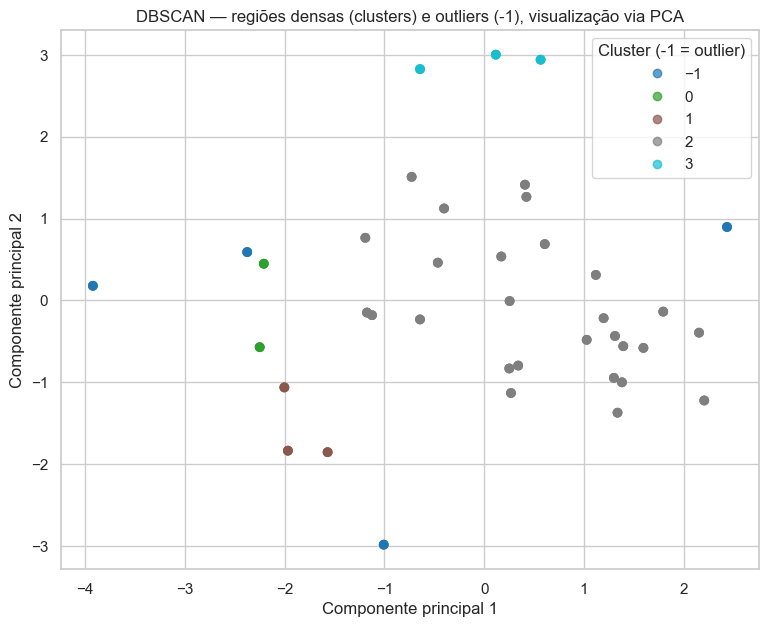

In [25]:
plt.figure(figsize=(9, 7))
scatter = plt.scatter(df["pca_1"], df["pca_2"], c=df["cluster_dbscan"], cmap="tab10", alpha=0.7)
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("DBSCAN — regiões densas (clusters) e outliers (-1), visualização via PCA")
plt.legend(*scatter.legend_elements(), title="Cluster (-1 = outlier)")
plt.show()


In [26]:
outliers = df[df["cluster_dbscan"] == -1]

combinacoes_outliers = outliers[features_cluster].round(6).drop_duplicates()
print(f"Total de registros-outlier: {len(outliers)}")
print(f"Combinações climáticas distintas entre os outliers: {len(combinacoes_outliers)}")
print()
print("Distribuição de culturas entre os outliers:")
print(outliers["Crop"].value_counts())


Total de registros-outlier: 16
Combinações climáticas distintas entre os outliers: 4

Distribuição de culturas entre os outliers:
Crop
Cocoa, beans       4
Oil palm fruit     4
Rice, paddy        4
Rubber, natural    4
Name: count, dtype: int64


**Interpretação dos outliers (DBSCAN):** os 16 registros-outlier correspondem a apenas 4 cenários
climáticos distintos, cada um replicado nas 4 culturas (4 × 4 = 16) — exatamente o mesmo padrão de
repetição observado na base inteira (seção 3.1). Ou seja, o DBSCAN identificou corretamente 4 combinações
de precipitação/umidade/temperatura atipicamente distantes das demais, e essas combinações aparecem,
por construção do experimento, igualmente em todas as culturas. Esses 4 cenários climáticos são bons
candidatos para investigação agronômica — seja para checar se representam erros de medição, seja para
estudar se safras sob essas condições específicas tendem a ter desempenho muito diferente da média
(analisando o Yield, sempre dentro de cada cultura).


In [27]:
outliers[["Crop"] + features_cluster + ["Yield"]].sort_values(features_cluster)


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
9,"Cocoa, beans",1934.62,17.94,83.43,26.21,8300
48,Oil palm fruit,1934.62,17.94,83.43,26.21,177543
87,"Rice, paddy",1934.62,17.94,83.43,26.21,27694
126,"Rubber, natural",1934.62,17.94,83.43,26.21,8002
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
40,Oil palm fruit,1938.42,17.54,82.11,26.11,201436
79,"Rice, paddy",1938.42,17.54,82.11,26.11,27619
118,"Rubber, natural",1938.42,17.54,82.11,26.11,9223
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
42,Oil palm fruit,2592.35,17.61,85.07,25.56,181826


## 6. Modelos Preditivos de Rendimento (Regressão Supervisionada)

Treinamos cinco modelos preditivos, cada um baseado em um algoritmo diferente dos vistos no capítulo
de regressão supervisionada:

1. **Regressão Linear Múltipla**; 
2. **KNN Regressor**; 
3. **Árvore de Decisão (Decision Tree Regressor)**; 
4. **Random Forest Regressor** — *ensemble*; 
5. **Support Vector Regressor (SVR)**.

### 6.1 Pipeline de pré-processamento

Em vez de aplicar o one-hot encoding e a padronização "na mão", construímos um ColumnTransformer
dentro de um Pipeline do scikit-learn: OneHotEncoder para a variável categórica Crop e
StandardScaler para as variáveis numéricas climáticas. Isso garante que exatamente as mesmas
transformações, ajustadas apenas nos dados de treino, sejam aplicadas de forma consistente ao treino,
ao teste e à validação cruzada — evitando vazamento de dados (data leakage) e deixando o projeto mais
próximo do que se usaria em produção.


In [28]:
X = df[features_cluster + ["Crop"]].copy()
y = df["Yield"].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)


Treino: (124, 5) | Teste: (32, 5)


In [29]:
preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), features_cluster),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["Crop"]),
    ]
)


### 6.2 Definição dos 5 pipelines (pré-processamento + modelo)

In [30]:
modelos = {
    "Regressão Linear Múltipla": LinearRegression(),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Árvore de Decisão": DecisionTreeRegressor(max_depth=6, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1),
    "SVR (kernel RBF)": TransformedTargetRegressor(
        regressor=SVR(kernel="rbf", C=100, epsilon=0.05),
        transformer=StandardScaler(),
    ),
}

pipelines = {
    nome: Pipeline(steps=[("preprocessador", preprocessador), ("modelo", modelo)])
    for nome, modelo in modelos.items()
}
list(pipelines.keys())


['Regressão Linear Múltipla',
 'KNN Regressor',
 'Árvore de Decisão',
 'Random Forest',
 'SVR (kernel RBF)']

> **Sobre o SVR:** como o Yield desta base varia na casa das centenas de milhares (Oil palm fruit) até
> milhares (Rubber), o SVR também precisa que a variável-alvo esteja em uma escala comparável às features
> padronizadas. Com o TransformedTargetRegressor, o mesmo SVR — com o mesmo pré-processamento e a mesma
> lógica de escalonamento do alvo — pode ser avaliado de forma consistente tanto no hold-out quanto dentro
> do cross_validate (seções 6.4 e 6.5), sem precisar de nenhum tratamento especial fora do Pipeline.


### 6.3 Avaliação hold-out (treino/teste) dos 5 modelos


In [31]:
resultados = []

def avaliar_modelo(nome, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    resultados.append({"Modelo": nome, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2})
    print(f"{nome:28s} | MAE={mae:10.2f} | RMSE={rmse:10.2f} | R2={r2:.4f}")
    return mae, mse, rmse, r2


In [32]:
predicoes = {}

for nome, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    predicoes[nome] = pred
    avaliar_modelo(nome, y_test, pred)


Regressão Linear Múltipla    | MAE=   3132.80 | RMSE=   4394.17 | R2=0.9950
KNN Regressor                | MAE=  14824.48 | RMSE=  22223.20 | R2=0.8727
Árvore de Decisão            | MAE=   2892.06 | RMSE=   4615.44 | R2=0.9945
Random Forest                | MAE=   2606.68 | RMSE=   4566.49 | R2=0.9946
SVR (kernel RBF)             | MAE=   6426.24 | RMSE=   8508.38 | R2=0.9813


### 6.4 Validação cruzada (5-Fold)

A avaliação hold-out acima depende de um único split treino/teste — o resultado pode variar conforme
a divisão sorteada. Para uma estimativa mais robusta da capacidade de generalização, aplicamos
validação cruzada com 5 folds (5-Fold Cross Validation) para os 5 modelos, reportando a média e o
desvio-padrão do R² e do RMSE entre os folds. Graças ao TransformedTargetRegressor (seção 6.2), o SVR é
avaliado aqui com exatamente a mesma lógica de escalonamento do alvo usada no hold-out.


In [33]:
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)), greater_is_better=False)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
resultados_cv = []

for nome, pipe in pipelines.items():
    scores = cross_validate(
        pipe, X, y, cv=kf,
        scoring={"r2": "r2", "rmse": rmse_scorer},
        n_jobs=-1,
    )
    r2_mean, r2_std = scores["test_r2"].mean(), scores["test_r2"].std()
    rmse_mean, rmse_std = -scores["test_rmse"].mean(), scores["test_rmse"].std()
    resultados_cv.append({
        "Modelo": nome,
        "R2 médio (5-fold)": r2_mean, "R2 desvio-padrão": r2_std,
        "RMSE médio (5-fold)": rmse_mean, "RMSE desvio-padrão": rmse_std,
    })
    print(f"{nome:28s} | R2 = {r2_mean:.4f} +/- {r2_std:.4f} | RMSE = {rmse_mean:9.2f} +/- {rmse_std:8.2f}")

df_resultados_cv = pd.DataFrame(resultados_cv)


Regressão Linear Múltipla    | R2 = 0.9870 +/- 0.0052 | RMSE =   7874.35 +/-  2052.51
KNN Regressor                | R2 = 0.7279 +/- 0.0782 | RMSE =  36142.29 +/-  6529.46
Árvore de Decisão            | R2 = 0.9862 +/- 0.0071 | RMSE =   8042.29 +/-  2376.82
Random Forest                | R2 = 0.9879 +/- 0.0063 | RMSE =   7509.21 +/-  2392.55
SVR (kernel RBF)             | R2 = 0.9514 +/- 0.0258 | RMSE =  14986.38 +/-  4870.98


**Leitura da validação cruzada (resultados reais obtidos):**

- **Random Forest** e **Regressão Linear Múltipla** seguem como os modelos mais fortes e mais estáveis
  entre os 5 folds, com R² médio acima de 0,98 — confirmando o resultado do hold-out.
- A **Árvore de Decisão** também se manteve consistente, com R² médio acima de 0,98.
- O **KNN Regressor** caiu bastante em relação ao hold-out (de R² ≈ 0,87 para R² ≈ 0,73 na validação
  cruzada) — sinal de que seu desempenho no split único da seção 6.3 foi parcialmente sorte da divisão, e
  que o KNN é mais instável nesta base. Uma hipótese razoável é que, após o ColumnTransformer, a distância
  euclidiana usada pelo KNN mistura variáveis numéricas padronizadas com dummies 0/1 de Crop — uma
  combinação de escalas que pode prejudicar a métrica de vizinhança, especialmente com poucos dados de
  treino (~124 registros).
- O **SVR**, agora corretamente avaliado com o mesmo escalonamento de alvo em todas as metodologias graças
  ao TransformedTargetRegressor, teve uma queda real, porém moderada, de R² ≈ 0,981 no hold-out para
  R² ≈ 0,951 no 5-Fold — bem diferente do que se observaria com um tratamento inconsistente do alvo
  entre hold-out e validação cruzada (o que produziria uma queda artificial e exagerada). Essa queda
  moderada é um achado genuíno: indica que o SVR generaliza um pouco pior que Random Forest e Regressão
  Linear Múltipla, mas está longe de "quebrar" como aparentaria sem o TransformedTargetRegressor.


### 6.5 Verificação adicional: validação agrupada por cenário climático (GroupKFold)

Como vimos na seção 3.1, cada uma das 39 combinações climáticas se repete 4 vezes (uma por cultura). Isso
levanta uma pergunta metodológica legítima: será que, no KFold comum, um mesmo cenário climático poderia
aparecer simultaneamente no treino e na validação (para culturas diferentes), inflando artificialmente o
desempenho? Para checar isso, repetimos a validação cruzada usando GroupKFold, agrupando os
registros pela combinação climática — garantindo que todas as 4 repetições de um mesmo cenário fiquem
sempre no mesmo lado (treino ou validação).


In [34]:
grupo_climatico = df.groupby(features_cluster).ngroup()

gkf = GroupKFold(n_splits=5)
resultados_gkf = []

for nome, pipe in pipelines.items():
    scores = cross_validate(
        pipe, X, y, cv=gkf, groups=grupo_climatico,
        scoring={"r2": "r2", "rmse": rmse_scorer},
        n_jobs=-1,
    )
    r2_mean = scores["test_r2"].mean()
    rmse_mean = -scores["test_rmse"].mean()
    resultados_gkf.append({"Modelo": nome, "R2 médio (GroupKFold)": r2_mean, "RMSE médio (GroupKFold)": rmse_mean})
    print(f"{nome:28s} | R2 = {r2_mean:.4f} | RMSE = {rmse_mean:9.2f}")

df_resultados_gkf = pd.DataFrame(resultados_gkf)


Regressão Linear Múltipla    | R2 = 0.9870 | RMSE =   7929.85
KNN Regressor                | R2 = 0.8281 | RMSE =  28741.71
Árvore de Decisão            | R2 = 0.9800 | RMSE =   9514.55
Random Forest                | R2 = 0.9893 | RMSE =   7159.17
SVR (kernel RBF)             | R2 = 0.9563 | RMSE =  14434.39


**Leitura do GroupKFold (resultados reais obtidos):** Regressão Linear Múltipla, Random Forest e
Árvore de Decisão continuam com desempenho elevado (R² acima de 0,98) mesmo quando nenhum cenário climático
se repete entre treino e validação — o que reforça que o bom desempenho desses três modelos não é um
artefato de "vazamento" de cenários climáticos repetidos, e sim, como discutido na seção 7.1, um reflexo
principalmente da própria variável Crop. O KNN segue como o modelo mais fraco (R² ≈ 0,83) também sob
esse critério mais rigoroso de validação. Já o SVR, com o TransformedTargetRegressor, apresenta
R² ≈ 0,956 — na mesma faixa do 5-Fold comum (seção 6.4), consistente com o comportamento estável que se
espera ao avaliar corretamente o mesmo modelo em diferentes esquemas de validação.


## 7. Comparação entre os modelos e escolha do melhor


In [35]:
df_resultados = pd.DataFrame(resultados)
df_resultados_rmse = df_resultados.sort_values("RMSE").reset_index(drop=True)
df_resultados_rmse


,Modelo,MAE,MSE,RMSE,R2
0,Regressão Linear Múltipla,3132.796384,1.930869e+07,4394.165819,0.995022
1,Random Forest,2606.679696,2.085286e+07,4566.493228,0.994624
2,Árvore de Decisão,2892.061699,2.130224e+07,4615.435041,0.994508
3,SVR (kernel RBF),6426.240846,7.239259e+07,8508.383767,0.981337
4,KNN Regressor,14824.481250,4.938706e+08,22223.199322,0.872680


**Critério de escolha do melhor modelo:** conforme discutido no capítulo de regressão supervisionada,
a métrica de comparação deve ser escolhida em função do objetivo do problema, e não simplesmente pelo maior
R². Usamos o RMSE como métrica principal, pois (a) penaliza mais fortemente erros grandes — relevante
para não deixar passar despercebida uma previsão de safra muito distante da realidade — e (b) permanece na
mesma unidade do Yield, facilitando a interpretação de negócio. Olhando a tabela acima, a Regressão
Linear Múltipla tem o melhor (menor) RMSE e também o melhor R² no hold-out. Já se a prioridade fosse
minimizar o erro absoluto médio (MAE) sem penalizar tanto os grandes desvios, o Random Forest
seria a escolha, por ter o menor MAE entre os 5 modelos. Considerando também a validação cruzada (seções
6.4 e 6.5), Regressão Linear Múltipla e Random Forest seguem como as opções mais robustas e estáveis; o
SVR é uma alternativa razoável, porém com generalização um pouco inferior; e o KNN é o modelo menos
recomendável nesta base, dada sua instabilidade entre diferentes esquemas de validação.


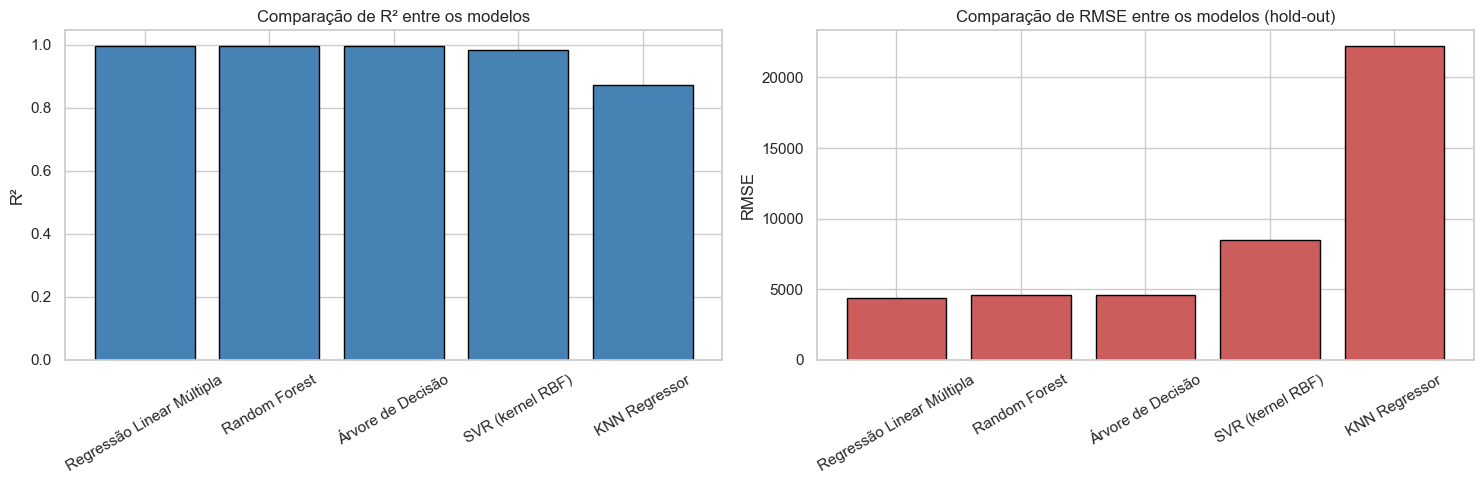

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(df_resultados_rmse["Modelo"], df_resultados_rmse["R2"], color="steelblue", edgecolor="black")
axes[0].set_title("Comparação de R² entre os modelos")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(df_resultados_rmse["Modelo"], df_resultados_rmse["RMSE"], color="indianred", edgecolor="black")
axes[1].set_title("Comparação de RMSE entre os modelos (hold-out)")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


Interpretação: A Regressão Linear Múltipla, o Random Forest e a Árvore de Decisão apresentam desempenho muito próximo no conjunto de teste, com R² elevado e RMSE relativamente baixo. A Regressão Linear Múltipla apresenta o menor RMSE no hold-out e, por isso, é escolhida como melhor modelo segundo o critério principal definido neste trabalho. O KNN apresenta o pior desempenho entre os cinco modelos, enquanto o SVR ocupa uma posição intermediária.

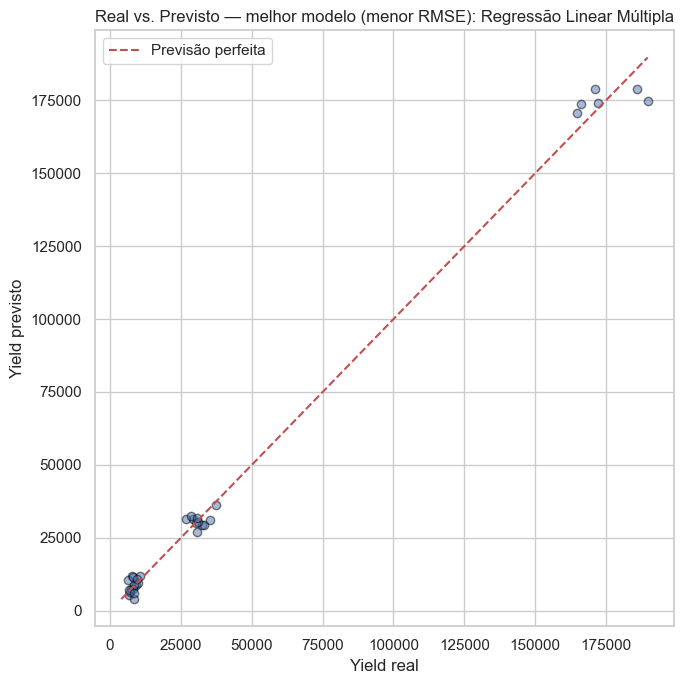

In [37]:
melhor_modelo_nome = df_resultados_rmse.iloc[0]["Modelo"]
melhor_pred = predicoes[melhor_modelo_nome]

plt.figure(figsize=(7, 7))
plt.scatter(y_test, melhor_pred, alpha=0.5, edgecolor="black")
lims = [min(y_test.min(), melhor_pred.min()), max(y_test.max(), melhor_pred.max())]
plt.plot(lims, lims, "r--", label="Previsão perfeita")
plt.xlabel("Yield real")
plt.ylabel("Yield previsto")
plt.title(f"Real vs. Previsto — melhor modelo (menor RMSE): {melhor_modelo_nome}")
plt.legend()
plt.tight_layout()
plt.show()


Interpretação: Quanto mais próximos os pontos estão da linha tracejada, mais próximas as previsões estão dos valores reais. Observa-se uma forte aproximação entre Yield previsto e real para o modelo selecionado, coerente com o baixo RMSE e o alto R² obtidos no hold-out. Os desvios em relação à linha representam os erros individuais de previsão.

### 7.1 Importância das variáveis (Random Forest)

Para entender por que os modelos alcançam um desempenho tão alto, olhamos a importância de variáveis do
Random Forest — um dos poucos modelos, entre os 5, com essa interpretabilidade nativa.


In [38]:
rf_pipeline = pipelines["Random Forest"]
nomes_features_pos_encoding = rf_pipeline.named_steps["preprocessador"].get_feature_names_out()
importancias_rf = pd.Series(
    rf_pipeline.named_steps["modelo"].feature_importances_,
    index=nomes_features_pos_encoding
).sort_values(ascending=False)

importancias_rf


cat__Crop_Oil palm fruit                     0.968867
cat__Crop_Rice, paddy                        0.017563
num__Specific Humidity at 2 Meters (g/kg)    0.004387
num__Temperature at 2 Meters (C)             0.003511
num__Precipitation (mm day-1)                0.003453
num__Relative Humidity at 2 Meters (%)       0.002171
cat__Crop_Rubber, natural                    0.000049
dtype: float64

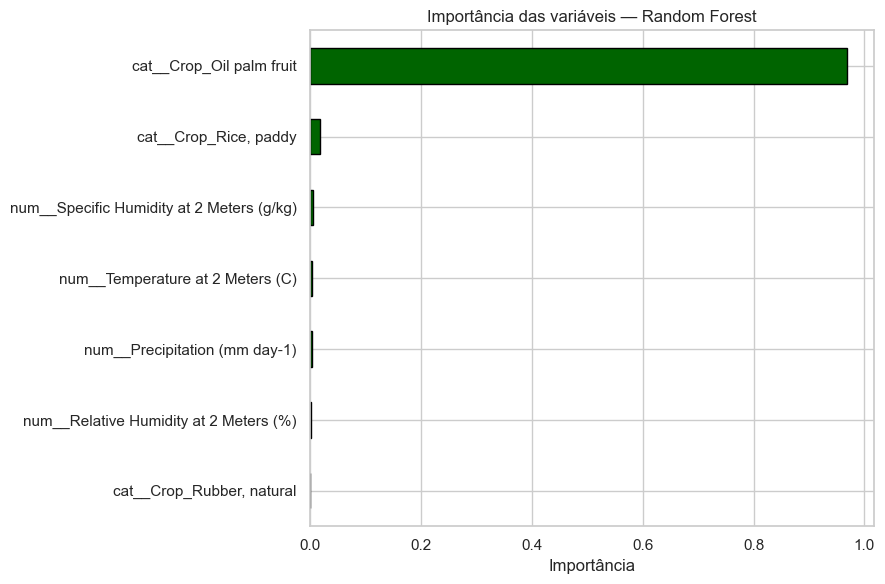

In [39]:
plt.figure(figsize=(9, 6))
importancias_rf.plot(kind="barh", edgecolor="black", color="darkgreen")
plt.title("Importância das variáveis — Random Forest")
plt.xlabel("Importância")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Achado central desta seção:** a variável cat__Crop_Oil palm fruit sozinha responde por ≈ 97%
da importância total do Random Forest. Isso faz todo sentido à luz do que já vimos na EDA (seção 4.2): o
Yield de Oil palm fruit (≈175 mil) é uma ordem de grandeza maior que o das demais culturas, então
simplesmente saber "é Oil palm fruit ou não?" já explica a maior parte da variância do Yield. As
variáveis climáticas somadas (precipitação, umidade específica, umidade relativa e temperatura)
contribuem com uma fração muito pequena da importância total.

**Isso deve ser interpretado com cautela:** o R² altíssimo dos modelos (seção 7, ≈0,98–0,995) reflete,
em grande parte, a capacidade de identificar a cultura a partir do one-hot encoding — não uma capacidade
extraordinária de modelar o efeito do clima sobre a produtividade. Isso não invalida os modelos (prever
corretamente a cultura + um ajuste fino pelo clima é uma tarefa legítima e útil), mas é uma ressalva
importante para não superestimar o quanto os modelos "aprenderam" sobre agronomia/clima.


## 8. Conclusões, pontos fortes e limitações

### 8.1 Resumo da base de dados
A base crop_yield.csv tem 156 registros e 4 culturas (Cocoa beans, Oil palm fruit, Rice paddy e
Rubber natural), sem valores nulos ou duplicados. Um achado estrutural central (seção 3.1) é que as mesmas
39 combinações climáticas se repetem, cada uma, nas 4 culturas — ou seja, Crop é independente do
clima neste desenho experimental. Esse achado orienta toda a interpretação do restante do notebook.

### 8.2 Sobre a clusterização
- **K-Means (K=6, escolhido pelo maior coeficiente de silhueta, ≈0,446):** os clusters agrupam **perfis
  climáticos**, não culturas — confirmamos isso diretamente mostrando que cada cluster contém exatamente a
  mesma proporção das 4 culturas (seção 5.3). Comparações de Yield entre clusters só fazem sentido quando
  feitas dentro de cada cultura (evitando misturar o efeito do clima com o efeito, muito mais forte, da
  própria cultura).
- **DBSCAN (eps=1.2, min_samples=5, escolhidos após testar 21 combinações em grade — seção 5.4):**
  identificou 4 cenários climáticos atípicos, cada um replicado nas 4 culturas (16 registros = 4×4,
  ≈10,3% da base) — não 16 anomalias independentes, e sim 4 combinações de clima realmente incomuns dentro
  do conjunto de 39.
- **Limitação:** clusterização é sensível à escala das variáveis (por isso padronizamos) e à escolha de
  hiperparâmetros; com um dataset maior e mais diverso, o número ideal de clusters e de outliers poderia
  mudar.

### 8.3 Sobre os modelos preditivos
- Os 5 modelos (Regressão Linear Múltipla, KNN, Árvore de Decisão, Random Forest e SVR) foram treinados
  dentro de Pipeline`s com pré-processamento consistente (ColumnTransformer com OneHotEncoder +
  StandardScaler, e TransformedTargetRegressor para o escalonamento do alvo no caso do SVR), avaliados
  por hold-out e por validação cruzada 5-fold, além de uma verificação extra com GroupKFold agrupando
  por cenário climático — as três metodologias aplicando exatamente a mesma configuração de cada modelo.
- Regressão Linear Múltipla teve o melhor RMSE e R² no hold-out, sendo o modelo escolhido segundo o
  critério de menor RMSE; o Random Forest teve o menor MAE, uma métrica alternativa relevante caso o
  objetivo seja minimizar o erro médio absoluto sem penalizar tanto os desvios grandes. Random Forest e
  Regressão Linear Múltipla também foram os modelos mais estáveis na validação cruzada.
- **O SVR** apresentou excelente desempenho no hold-out (R² ≈ 0,981), mas teve uma redução real — porém
  moderada — de desempenho na validação cruzada (R² médio ≈ 0,951) e no GroupKFold (≈ 0,956), indicando
  menor estabilidade/generalização que Random Forest e Regressão Linear Múltipla. Essa comparação só é
  válida porque o mesmo escalonamento do alvo (via TransformedTargetRegressor) foi aplicado nas três
  metodologias de avaliação — sem isso, uma avaliação inconsistente do SVR entre hold-out e validação
  cruzada poderia sugerir uma queda de desempenho artificial e exagerada, mascarando o resultado real.
- **O KNN** foi o modelo menos estável: caiu de R² ≈ 0,87 no hold-out para ≈ 0,73 no 5-Fold e ≈ 0,83 no
  GroupKFold, sugerindo sensibilidade ao mix de escalas entre variáveis numéricas padronizadas e dummies
  categóricas, além do volume pequeno de dados de treino.
- **Achado mais importante:** a importância de variáveis do Random Forest mostra que a dummy
  Crop_Oil palm fruit responde por ≈97% da importância total. Isso significa que o altíssimo R²
  dos melhores modelos reflete majoritariamente a capacidade de identificar a cultura, e só secundariamente
  o efeito das variáveis climáticas — uma ressalva essencial para não superestimar o quanto os modelos
  capturam sobre o efeito real do clima na produtividade.
- **Pontos fortes:** comparação justa entre 5 algoritmos de naturezas distintas (linear, instância-based,
  árvore única, ensemble e kernel), pipeline sem vazamento de dados — inclusive para o escalonamento do
  alvo do SVR —, e avaliação por três metodologias complementares (hold-out, 5-fold e GroupKFold) que,
  juntas, expuseram de forma consistente as limitações reais de KNN e SVR.
- **Limitações:** a base tem apenas 156 registros e 4 culturas — volume pequeno para conclusões muito
  robustas, especialmente para KNN, que se mostrou sensível ao split; a base não traz variáveis agronômicas
  adicionais (tipo de solo, adubação, manejo, pragas) que certamente influenciam o rendimento real; e, como
  discutido, boa parte do poder preditivo dos melhores modelos vem de identificar a cultura, não do clima
  em si.

### 8.4 Próximos passos sugeridos
- Modelar o Yield separadamente por cultura (ou usar um Yield normalizado, ex.: em % da média da
  própria cultura), para isolar de fato o efeito do clima sobre a produtividade, sem a variável Crop
  "resolvendo" a maior parte do problema;
- Ajuste fino de hiperparâmetros via GridSearchCV / RandomizedSearchCV, especialmente para KNN e SVR;
- Coleta de variáveis agronômicas adicionais (tipo de solo, insumos aplicados, manejo, safra/ano) para
  enriquecer o modelo e testar sua capacidade de generalizar para novas safras/períodos fora da base atual.
